# **OKCupid Date-a-Scientist**

##### By Faatimah Majothi

### Introduction

In this project, we will be analysing data from OKCupid, a dating app that focuses on using multiple choice and short answers to match users. We will attempt to build, train, and evaluate a machine learning model that predicts a target aspect of user profiles based on the other features in the dataset.
The data in this project was provided by [Codecademy's OKCupid machine learning project page](https://www.codecademy.com/paths/data-science/tracks/dscp-machine-learning-portfolio-project/modules/dscp-okcupid-date-a-scientist/kanban_projects/okcupid-date-a-scientist-portfolio-project#skip-content-tasks).

### Project Scope

This project aims to:
1. Load and analyse the data of the profiles in **`profiles.csv`**
2. Clean and transform the data for training machine learning models
3. Implement machine learning algorithms to predict the smoker status of users based on features


We will practice exploratory data analysis (EDA), data cleaning, feature engineering, model building and training, and model evaluation. Three models will be trained to predict users' smoker status based on profile features. We will train a decision tree classifier, a logistic regression model and a K-Nearest Neighbors (KNN) model. Lastly, we will compare the predictive capabilities of the models to determine which of them had the highest accuracy.

## **Section A:** Data Setup

To begin with, the libraries necessary for data handling, visualisation and machine learning processes are imported.

In [3]:
# Initialise Libraries

# Data Handling
import pandas as pd
import numpy as np

# Visualisation
from matplotlib import pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,\
confusion_matrix, classification_report, ConfusionMatrixDisplay

# Plot colour parameters
plt.rcParams['figure.facecolor'] = '#F5D9D7'
plt.rcParams['axes.facecolor'] = '#FFFFFF'

Next, the first few lines of the dataset are previewed to get an idea of the columns and a glimpse of the possible rows.

In [4]:
# Import data
profiles = pd.read_csv('profiles.zip')

# Preview
profiles.head(2)

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single


At first glance, it appears that the columns with the word 'essay' in them are free responses to questions. A look at the original dataset on excel sheds more light on the questions asked. Since the essay questions were open ended, we had to look at a few of the responses to infer the questions asked.

| Column   | Possible Question Asked                            |
|----------|----------------------------------------------------|
| essay0   | Decribing myself in a nutshell:                    |
| essay1   | What am I currently pursuing?                      |
| essay2   | What am I good at?                                 |
| essay3   | First thing people notice about me:                |
| essay4   | What is my favourite pastime?                      |
| essay5   | Six things I wouldn't want to live without:        |
| essay6   | What do I spend time thinking about?               |
| essay7   | I spend my friday nights doing:                    |
| essay8   | A private fact about me:                           |
| essay9   | What kind of person am I looking for?              |

Excluding these open-ended questions, we can then take a look at the summary statistics of the columns and display further information using `.describe()` and `.info()`

In [5]:
# Exclude essay columns
profile_essays = profiles[[col for col in profiles.columns if 'essay' in col]]
profiles_features = profiles.drop(profile_essays, axis=1)
profiles_features = profiles_features.drop('last_online', axis=1)

# Summary statistics
print(profiles_features.describe())

# Column information
print(profile_essays.info())
profiles_features.info()

                age        height          income
count  59946.000000  59943.000000    59946.000000
mean      32.340290     68.295281    20033.222534
std        9.452779      3.994803    97346.192104
min       18.000000      1.000000       -1.000000
25%       26.000000     66.000000       -1.000000
50%       30.000000     68.000000       -1.000000
75%       37.000000     71.000000       -1.000000
max      110.000000     95.000000  1000000.000000
<class 'pandas.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   essay0  54458 non-null  str  
 1   essay1  52374 non-null  str  
 2   essay2  50308 non-null  str  
 3   essay3  48470 non-null  str  
 4   essay4  49409 non-null  str  
 5   essay5  49096 non-null  str  
 6   essay6  46175 non-null  str  
 7   essay7  47495 non-null  str  
 8   essay8  40721 non-null  str  
 9   essay9  47343 non-null  str  
dtypes: str(10)
memory usage: 4.

Three of the columns, **`age`**, **`height`** and **`income`** appear to be both numerical and continuous while the rest are categorical. Many of the columns appear to have null values. We can find which ones with the following code.

In [6]:
# Find columns with nulls and print column names and null counts
null_counts = profiles_features.isnull().sum()
has_nulls = null_counts[null_counts > 0]
has_nulls

body_type     5296
diet         24395
drinks        2985
drugs        14080
education     6628
ethnicity     5680
height           3
job           8198
offspring    35561
pets         19921
religion     20226
sign         11056
smokes        5512
speaks          50
dtype: int64

It is clear that some columns have far more nulls than others, such as the **`diet`**, **`offspring`** and **`religion`** columns. This suggests that many people were uncomfortable answering them due to the sensitivity of the topics. For this project, null rows will be removed to try and improve the machine learning models' accuracy. This is a limitation of the project, as we will be excluding a sizeable portion of data. 

## **Section B:** Exploratory Data Analysis

Moving on to the EDA (Exploratory Data Analysis) step, we will be focusing on visualising aspects of the columns in `profiles_features`, excluding the essay questions. 
To begin with, we will take a look at the distributions of the numerical features in the `age`, `height` and `income` columns.

#### **Numeric Features**:

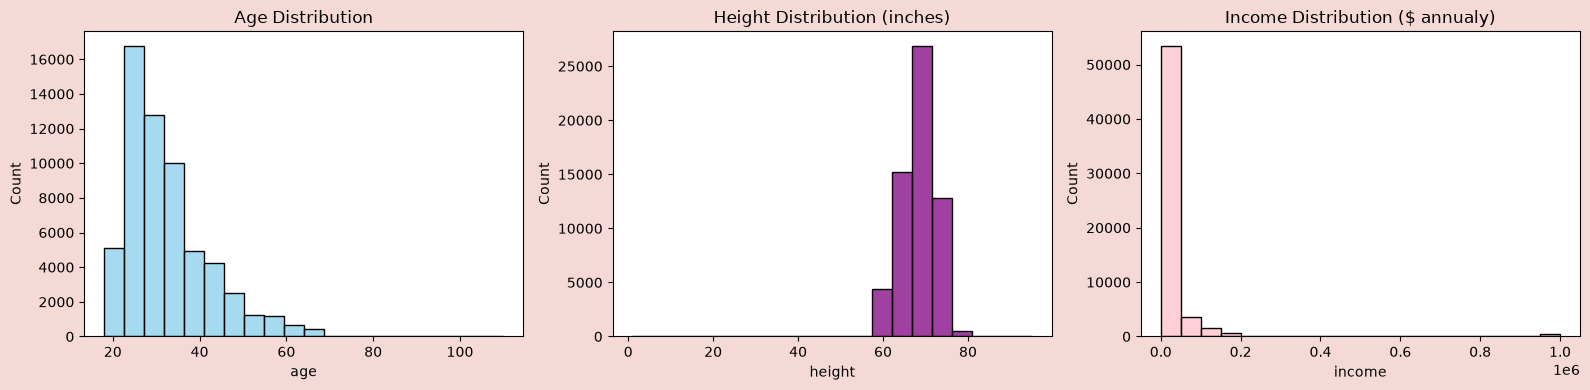

In [7]:
# Visualising the distributions of age, height and income in the dataset
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(profiles_features['age'], bins=20, color='skyblue', ax=ax[0])
ax[0].set_title('Age Distribution')

sns.histplot(profiles_features['height'], bins=20, color='purple', ax=ax[1])
ax[1].set_title('Height Distribution (inches)')

sns.histplot(profiles_features['income'], bins=20, color='pink', ax=ax[2])
ax[2].set_title('Income Distribution ($ annualy)')

plt.tight_layout()
plt.savefig('ageheightincomehist.png', bbox_inches='tight')
plt.show()
plt.close()

The range of the distribution of some of the features, such as the lowest `height` value and highest `age` value do not make sense. These may be errors or outliers in the data. As a reminder, the summary statistics of the three columns were as follows:

In [8]:
# Summary statistics
print(profiles_features.describe())

                age        height          income
count  59946.000000  59943.000000    59946.000000
mean      32.340290     68.295281    20033.222534
std        9.452779      3.994803    97346.192104
min       18.000000      1.000000       -1.000000
25%       26.000000     66.000000       -1.000000
50%       30.000000     68.000000       -1.000000
75%       37.000000     71.000000       -1.000000
max      110.000000     95.000000  1000000.000000


The minimum `height` value of 1 is clearly an **error or incorrect entry**, and the maximum `age` value of **110 is unlikely to be the real age** of a user on a dating app. The distribution of `income` is also skewed, with most of the entries being '**-1**' in place of missing data. This will need further investigation and cleaning before the data can be used to train a machine learning model.

In [9]:
# Investigate age outliers and drop rows with ages above 80
print(profiles_features[profiles_features['age']>80])
profiles_features = profiles_features[profiles_features['age'] <= 80]

       age body_type          diet drinks  drugs                   education  \
2512   110       NaN           NaN    NaN    NaN                         NaN   
25324  109  athletic  mostly other    NaN  never  working on masters program   

      ethnicity  height  income      job                   location  \
2512        NaN    67.0      -1      NaN      daly city, california   
25324       NaN    95.0      -1  student  san francisco, california   

             offspring orientation pets                             religion  \
2512               NaN    straight  NaN                                  NaN   
25324  might want kids    straight  NaN  other and somewhat serious about it   

      sex                                  sign         smokes  \
2512    f                                   NaN            NaN   
25324   m  aquarius but it doesn&rsquo;t matter  when drinking   

               speaks     status  
2512          english     single  
25324  english (okay)  available  


It is unlikely that anyone over the age of 80 would be using a dating site, so the rows with `age` above 80 will be dropped.

In [10]:
# Investigate height outliers
print(profiles_features['height'][profiles_features['height']<55].value_counts())
print (profiles_features['height'][profiles_features['height']>80].value_counts())
profiles_features = profiles_features[(profiles_features['height'] >= 50) & (profiles_features['height'] <= 80)]

height
36.0    11
53.0     5
54.0     3
43.0     2
50.0     2
48.0     2
37.0     2
52.0     1
8.0      1
3.0      1
42.0     1
6.0      1
47.0     1
49.0     1
9.0      1
51.0     1
1.0      1
26.0     1
4.0      1
Name: count, dtype: int64
height
95.0    19
83.0    12
81.0    11
82.0    11
84.0     9
91.0     3
94.0     3
88.0     2
87.0     1
93.0     1
86.0     1
90.0     1
92.0     1
85.0     1
89.0     1
Name: count, dtype: int64


Since the average human height falls within the bounds of the range [4'5 - 6'6] (inclusive to both men and women), we can drop any rows with heights outside of this range, as they are likely to be outliers. This range of height was chosen as it corresponds to the range between 55 to 80 inches.

In [11]:
# Investigate income negative values and replace with NaNs
print(profiles_features['income'][profiles_features['income']<1000].value_counts())
profiles['income'] = profiles['income'].replace(-1, np.nan)

income
-1    48370
Name: count, dtype: int64


Lastly, any rows with incomes below $1000 were replaced with NaN values, as the negatives correspond to empty entries. With these changes made, the three adjusted variables can be plotted once again.

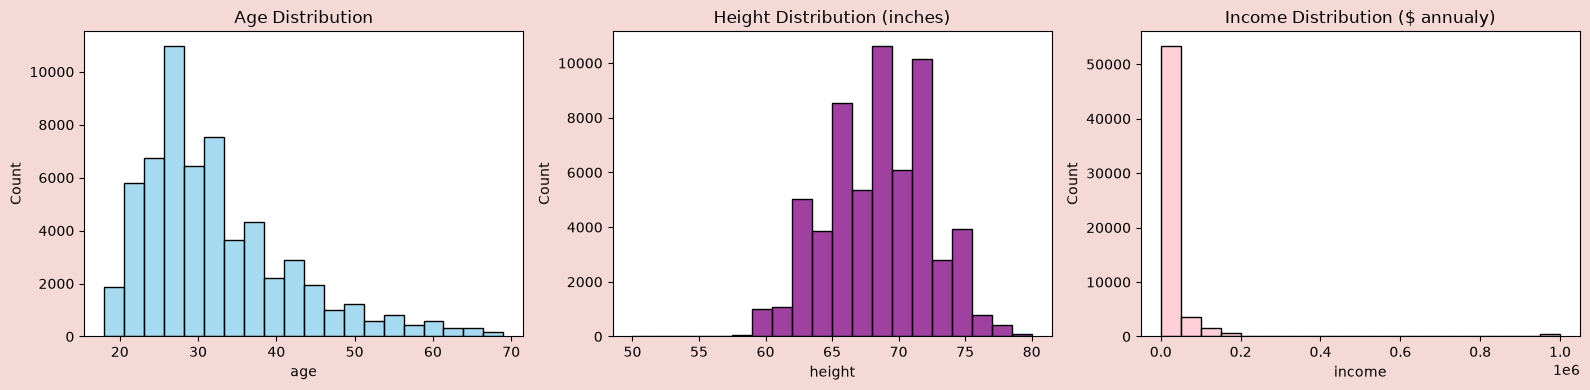

In [12]:
# Visualising the adjusted distributions of age, height and income 
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(profiles_features['age'], bins=20, color='skyblue', ax=ax[0])
ax[0].set_title('Age Distribution')

sns.histplot(profiles_features['height'], bins=20, color='purple', ax=ax[1])
ax[1].set_title('Height Distribution (inches)')

sns.histplot(profiles_features['income'], bins=20, color='pink', ax=ax[2])
ax[2].set_title('Income Distribution ($ annualy)')

plt.tight_layout()
plt.savefig('adjageheightincomehist.png', bbox_inches='tight')
plt.show()
plt.close()

In [13]:
# Summary statistics
print(profiles_features.describe())

                age        height          income
count  59837.000000  59837.000000    59837.000000
mean      32.342531     68.287381    19839.090028
std        9.442668      3.842655    96412.241449
min       18.000000     50.000000       -1.000000
25%       26.000000     66.000000       -1.000000
50%       30.000000     68.000000       -1.000000
75%       37.000000     71.000000       -1.000000
max       69.000000     80.000000  1000000.000000


The summary statistics are now a little clearer. The income column is still highly skewed, but we will ignore it for the time being.

##### **Categorical Features**:

Moving on to the categorical columns, we will explore the distributions of each. First we will look at the unique values in each. Then we will visualise the distributions.

In [14]:
# Unique values in each categorical column
categorical_cols = profiles_features.select_dtypes(include=['object','string']).columns

[print(f'{col} column: \n', profiles_features[col].unique(),'\n') for col in categorical_cols]

body_type column: 
 <StringArray>
['a little extra',        'average',           'thin',       'athletic',
            'fit',              nan,         'skinny',          'curvy',
   'full figured',         'jacked', 'rather not say',        'used up',
     'overweight']
Length: 13, dtype: str 

diet column: 
 <StringArray>
[  'strictly anything',        'mostly other',            'anything',
          'vegetarian',                   nan,     'mostly anything',
   'mostly vegetarian',      'strictly vegan', 'strictly vegetarian',
        'mostly vegan',      'strictly other',        'mostly halal',
               'other',               'vegan',       'mostly kosher',
      'strictly halal',               'halal',     'strictly kosher',
              'kosher']
Length: 19, dtype: str 

drinks column: 
 <StringArray>
['socially', 'often', 'not at all', 'rarely', nan, 'very often',
 'desperately']
Length: 7, dtype: str 

drugs column: 
 <StringArray>
['never', 'sometimes', nan, 'often']
Le

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

We can see that many columns, such as `diet`, `religion` and `sign` can be summarised into main categories. We will do this to make the visualisations easier to understand.

sex
m    35743
f    24094
Name: count, dtype: int64


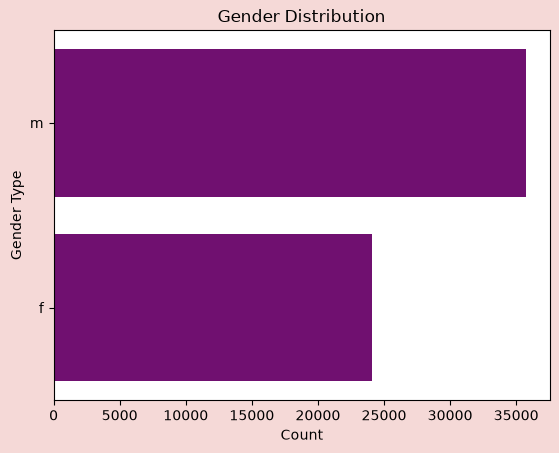

In [56]:
# Plot sex column distribution 
print(profiles_features['sex'].value_counts())

sns.countplot(data=profiles_features, y='sex', order=profiles_features['sex'].value_counts().index, color='purple')
plt.title('Gender Distribution')
plt.xlabel('Count')
plt.ylabel('Gender Type')
plt.show()

body_type
average           14639
fit               12697
athletic          11790
thin               4710
curvy              3921
a little extra     2626
skinny             1776
full figured       1009
overweight          442
jacked              409
used up             343
rather not say      197
Name: count, dtype: int64


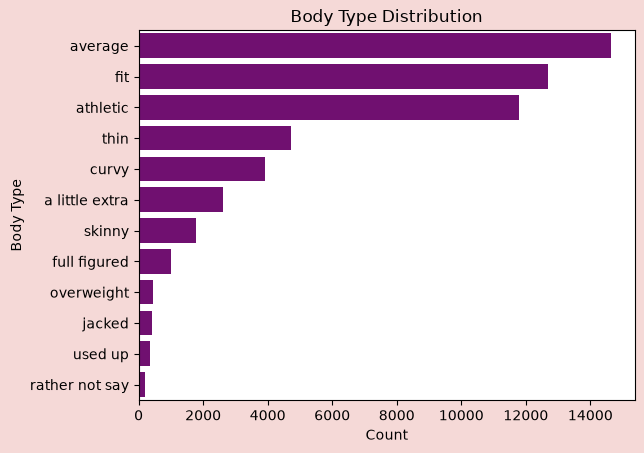

In [57]:
# Plot body_type column distribution 
print(profiles_features['body_type'].value_counts())

sns.countplot(data=profiles_features, y='body_type', order=profiles_features['body_type'].value_counts().index, color='purple')
plt.title('Body Type Distribution')
plt.xlabel('Count')
plt.ylabel('Body Type')
plt.show()

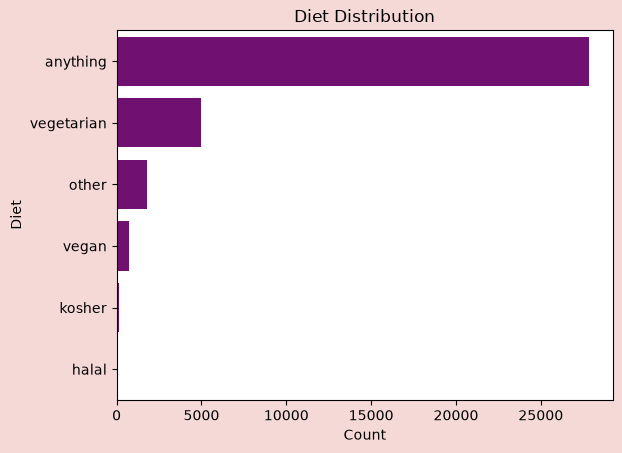

In [58]:
# Clean diet column 
profiles_features['diet_cleaned'] = profiles_features['diet'].str.split().str[-1]

# Plot diet column distribution 
sns.countplot(data=profiles_features, y='diet_cleaned', order=profiles_features['diet_cleaned'].value_counts().index, color='purple')
plt.title('Diet Distribution')
plt.xlabel('Count')
plt.ylabel('Diet')
plt.show()

drinks
socially       41726
rarely          5951
often           5154
not at all      3258
very often       466
desperately      316
Name: count, dtype: int64


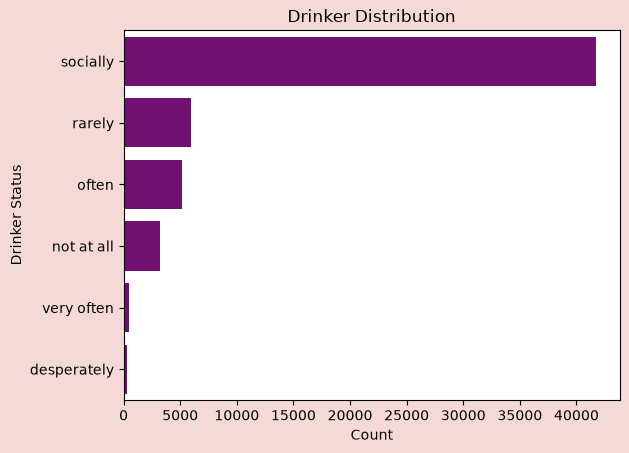

In [59]:
# Plot drinks column distribution 
print(profiles_features['drinks'].value_counts())

sns.countplot(data=profiles_features, y='drinks', order=profiles_features['drinks'].value_counts().index, color='purple')
plt.title('Drinker Distribution')
plt.xlabel('Count')
plt.ylabel('Drinker Status')
plt.show()

drugs
never        37662
sometimes     7716
often          400
Name: count, dtype: int64


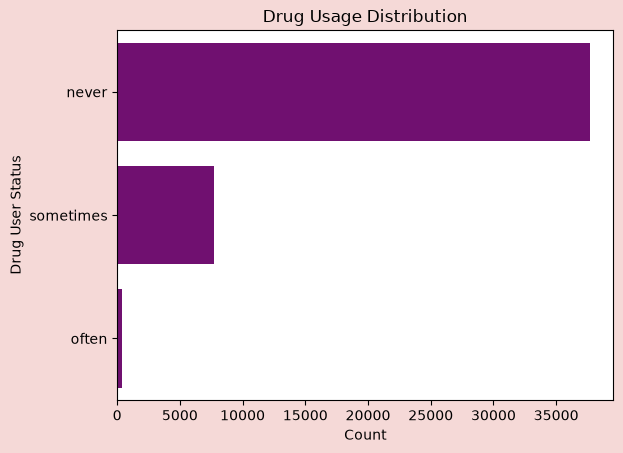

In [60]:
# Plot drugs column distribution 
print(profiles_features['drugs'].value_counts())

sns.countplot(data=profiles_features, y='drugs', order=profiles_features['drugs'].value_counts().index, color='purple')
plt.title('Drug Usage Distribution')
plt.xlabel('Count')
plt.ylabel('Drug User Status')
plt.show()

smokes
no                43841
sometimes          3777
when drinking      3030
yes                2221
trying to quit     1477
Name: count, dtype: int64


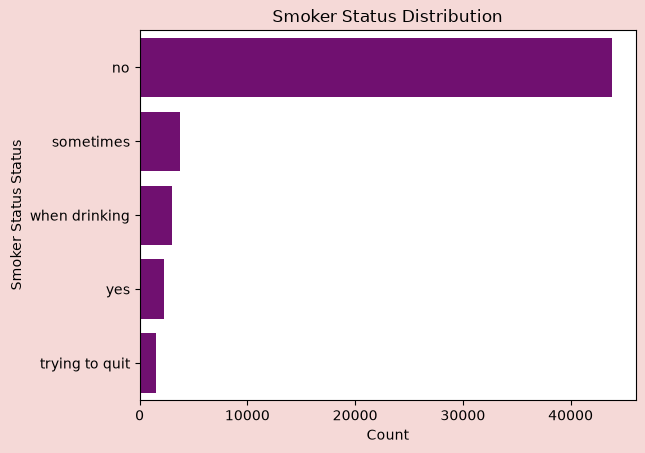

In [61]:
# Plot smoker column distribution 
print(profiles_features['smokes'].value_counts())

sns.countplot(data=profiles_features, y='smokes', order=profiles_features['smokes'].value_counts().index, color='purple')
plt.title('Smoker Status Distribution')
plt.xlabel('Count')
plt.ylabel('Smoker Status Status')
plt.show()

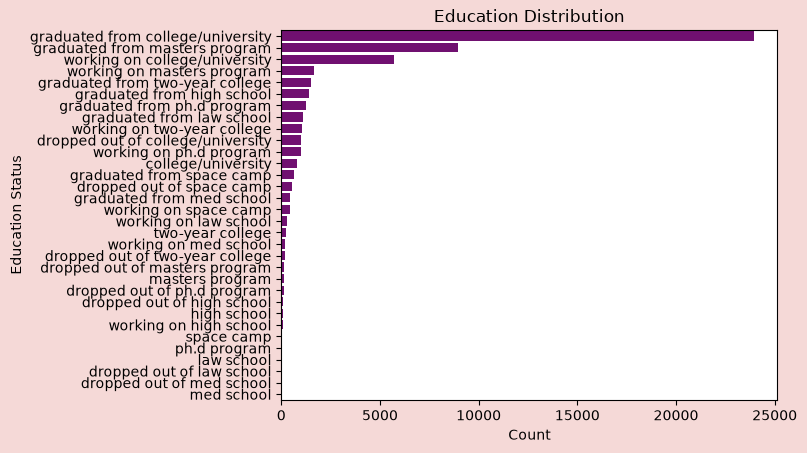

In [62]:
# Plot education distribution
sns.countplot(data=profiles_features, y='education', order=profiles_features['education'].value_counts().index, color='purple')
plt.title('Education Distribution')
plt.xlabel('Count')
plt.ylabel('Education Status')
plt.show()

job
other                                7578
student                              4869
science / tech / engineering         4843
computer / hardware / software       4702
artistic / musical / writer          4430
sales / marketing / biz dev          4389
medicine / health                    3679
education / academia                 3509
executive / management               2369
banking / financial / real estate    2265
entertainment / media                2243
law / legal services                 1379
hospitality / travel                 1362
construction / craftsmanship         1019
clerical / administrative             805
political / government                705
rather not say                        433
transportation                        365
unemployed                            272
retired                               249
military                              201
Name: count, dtype: int64


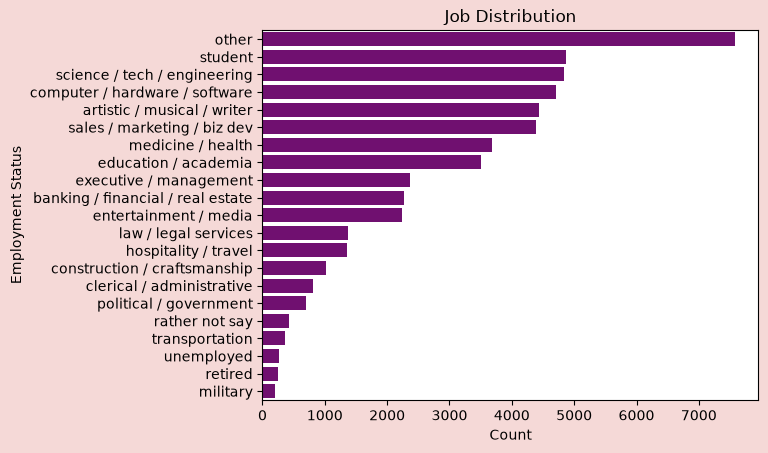

In [63]:
# Plot job column distribution 
print(profiles_features['job'].value_counts())

# Plot job role distribution
sns.countplot(data=profiles_features, y='job', order=profiles_features['job'].value_counts().index, color='purple')
plt.title('Job Distribution')
plt.xlabel('Count')
plt.ylabel('Employment Status')
plt.show()

offspring
doesn't have kids                          7547
doesn't have kids, but might want them     3871
doesn't have kids, but wants them          3561
doesn't want kids                          2919
has kids                                   1880
has a kid                                  1879
doesn't have kids, and doesn't want any    1131
has kids, but doesn't want more             442
has a kid, but doesn't want more            274
has a kid, and might want more              230
wants kids                                  225
might want kids                             181
has kids, and might want more               115
has a kid, and wants more                    71
has kids, and wants more                     21
Name: count, dtype: int64


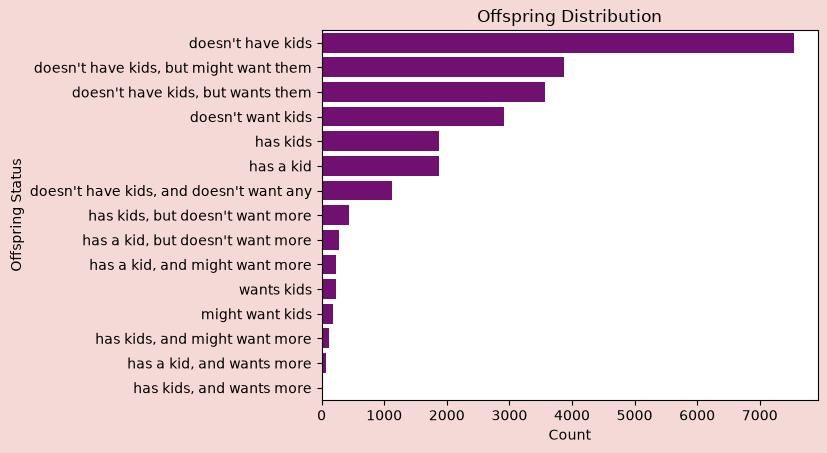

In [64]:
# Clean offspring column
profiles_features['offspring'] = profiles_features['offspring'].str.replace('&rsquo;', "'")

# Plot offspring column distribution 
print(profiles_features['offspring'].value_counts())

# Plot offspring distribution
sns.countplot(data=profiles_features, y='offspring', order=profiles_features['offspring'].value_counts().index, color='purple')
plt.title('Offspring Distribution')
plt.xlabel('Count')
plt.ylabel('Offspring Status')
plt.show()

orientation
straight    51505
gay          5569
bisexual     2763
Name: count, dtype: int64


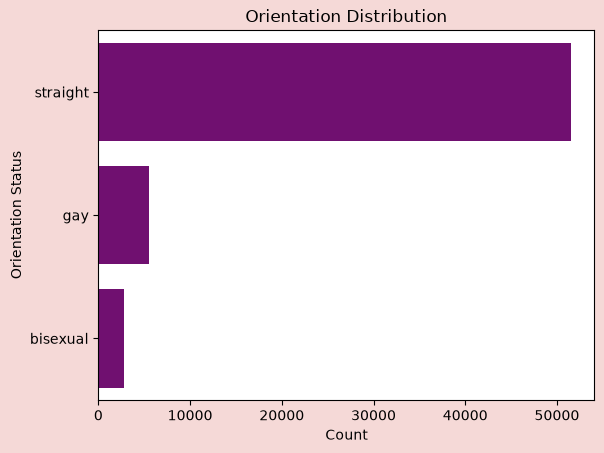

In [65]:
# Plot orientation column distribution 
print(profiles_features['orientation'].value_counts())

# Plot orientation distribution
sns.countplot(data=profiles_features, y='orientation', order=profiles_features['orientation'].value_counts().index, color='purple')
plt.title('Orientation Distribution')
plt.xlabel('Count')
plt.ylabel('Orientation Status')
plt.show()

pets
likes dogs and likes cats          14788
likes dogs                          7217
likes dogs and has cats             4308
has dogs                            4127
has dogs and likes cats             2327
likes dogs and dislikes cats        2026
has dogs and has cats               1470
has cats                            1402
likes cats                          1060
has dogs and dislikes cats           549
dislikes dogs and likes cats         237
dislikes dogs and dislikes cats      194
dislikes cats                        122
dislikes dogs and has cats            81
dislikes dogs                         44
Name: count, dtype: int64


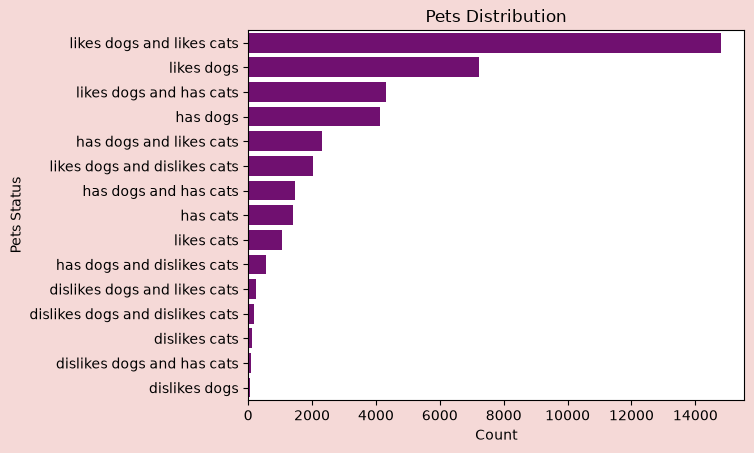

In [66]:
# Plot pets column distribution 
print(profiles_features['pets'].value_counts())

# Plot orientation distribution
sns.countplot(data=profiles_features, y='pets', order=profiles_features['pets'].value_counts().index, color='purple')
plt.title('Pets Distribution')
plt.xlabel('Count')
plt.ylabel('Pets Status')
plt.show()

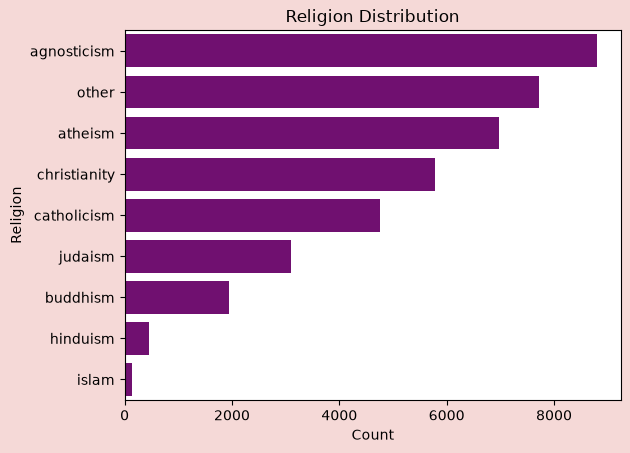

In [55]:
# Clean religion column 
profiles_features['religion_cleaned'] = profiles_features['religion'].str.split().str[0]

# Plot diet column distribution 
sns.countplot(data=profiles_features, y='religion_cleaned', order=profiles_features['religion_cleaned'].value_counts().index, color='purple')
plt.title('Religion Distribution')
plt.xlabel('Count')
plt.ylabel('Religion')
plt.show()

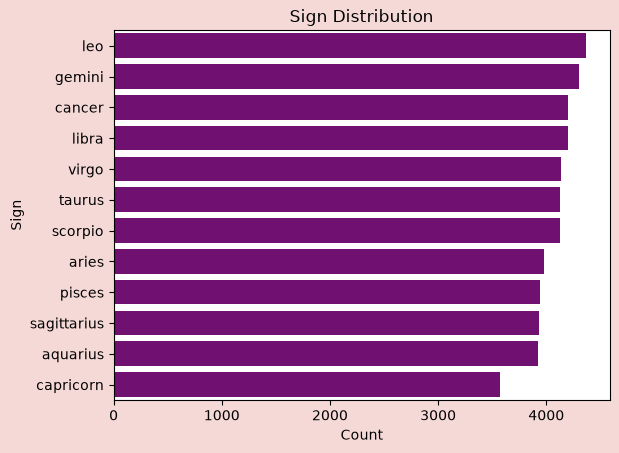

In [54]:
# Clean sign column 
profiles_features['sign_cleaned'] = profiles_features['sign'].str.split().str[0]

# Plot diet column distribution 
sns.countplot(data=profiles_features, y='sign_cleaned', order=profiles_features['sign_cleaned'].value_counts().index, color='purple')
plt.title('Sign Distribution')
plt.xlabel('Count')
plt.ylabel('Sign')
plt.show()

status
single            55596
seeing someone     2059
available          1863
married             309
unknown              10
Name: count, dtype: int64


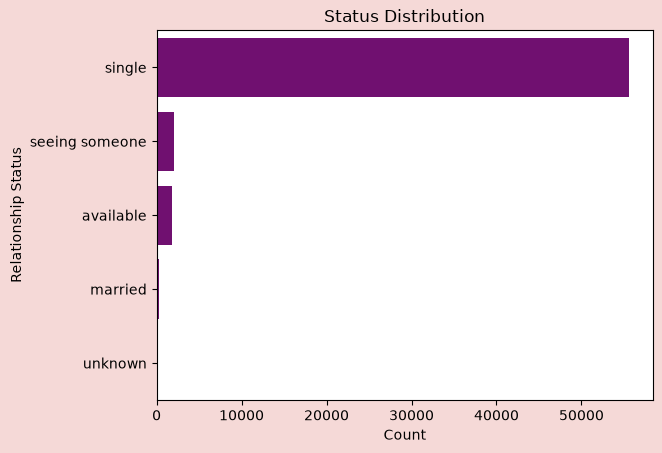

In [53]:
# Clean status column 
print(profiles_features['status'].value_counts())

# Plot diet column distribution 
sns.countplot(data=profiles_features, y='status', order=profiles_features['status'].value_counts().index, color='purple')
plt.title('Status Distribution')
plt.xlabel('Count')
plt.ylabel('Relationship Status')
plt.show()

### Exploratory Data Analysis Summary
The EDA of the OKCupid dataset reveals some key insights about the users. Some notable points are listed below:
- **Age:**
Most users are in their late 20s to early 30s, with a mean age of about 32 years.
- **Gender:**
There are more men than women in the dataset.
- **Religion, Job, and Zodiac:**
There is a wide range of religions and job roles among users in the dataset, with unequal distributions. Zodiac signs are relatively equally distributed. 
- **Pets, Offspring and Orientation:**
Most of the users like both dogs and cats, and most are childless. The majority of users are straight, but other orientations are present.
- **Status:**
Most of the users are single, but curiously, there are exceptions.
- **Smokes:**
Most of the users do not smoke, but there are a range who do smoke conditionally or otherwise. This will be handled in the next section

Overall, the features of the dataset are diverse, which will provide a good foundation for building and evaluating predictive models. The variety in user backgrounds, preferences, and demographics will potentially allow us to uncover interesting patterns related to user profiles and smoker status.

## **Section C:** Data Preprocessing

In this section, we will focus on cleaning and preprocessing the data for model training. The steps we will follow are listed below.

- **Data Cleaning:**
We will drop rows with missing values to clean the dataset before modeling. 

- **Feature Selection:**
We will subset relevant columns from the original profiles DataFrame, focusing on categorical features. This is because the numerical `height`, `age` and `income` features could introduce bias or noise into the models.

- **One-Hot Encoding:**
For our categorical features, we will be using one-hot encoding to convert the features into a format that the machine learning algorithms can interpret.

- **Target Label Encoding:**
The `smokes` column contains several categories aside from `no` smoker status. We will convert these into a binary label: users who answered no will be labeled as non-smokers, while all other responses will be labeled as smokers. This will create a clear distinction for the classification task.


- **Train-test Split:**
Finally, we will split the data into features (X) and labels (Y), before using a train_test_split to split the clean dataset into training and validation sets. This will allow us to train the models and evaluate them on real data before making predictions.

In [52]:
# Clean DataFrame
profiles_clean = profiles_features.dropna()

# Preview
print('Cleaned profiles DataFrame summary:', profiles_clean.info())
print(profiles_clean.isnull().sum())

<class 'pandas.DataFrame'>
Index: 7114 entries, 0 to 59944
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               7114 non-null   int64  
 1   body_type         7114 non-null   str    
 2   diet              7114 non-null   str    
 3   drinks            7114 non-null   str    
 4   drugs             7114 non-null   str    
 5   education         7114 non-null   str    
 6   ethnicity         7114 non-null   str    
 7   height            7114 non-null   float64
 8   income            7114 non-null   int64  
 9   job               7114 non-null   str    
 10  location          7114 non-null   str    
 11  offspring         7114 non-null   str    
 12  orientation       7114 non-null   str    
 13  pets              7114 non-null   str    
 14  religion          7114 non-null   str    
 15  sex               7114 non-null   str    
 16  sign              7114 non-null   str    
 17  smokes    

#### **Feature Selection:**

In [67]:
# Feature selection
feat_cols = ['sex', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'offspring', 'orientation', 'religion_cleaned']
X = profiles_clean[feat_cols]

# Preview
print('Feature DataFrame shape:', X.shape)
X.head()

Feature DataFrame shape: (7114, 9)


,sex,body_type,diet,drinks,drugs,education,offspring,orientation,religion_cleaned
0,m,a little extra,strictly anything,socially,never,working on college/university,"doesn't have kids, but might want them",straight,agnosticism
1,m,average,mostly other,often,sometimes,working on space camp,"doesn't have kids, but might want them",straight,agnosticism
7,f,average,mostly anything,socially,never,graduated from college/university,"doesn't have kids, but wants them",straight,christianity
14,f,thin,mostly anything,socially,never,working on college/university,"doesn't have kids, but wants them",straight,catholicism
19,m,athletic,mostly anything,socially,never,graduated from masters program,doesn't have kids,straight,catholicism


#### **One-Hot Encoding:**

In [68]:
# Encode feature columns
X = pd.get_dummies(X)
X.head()

,sex_f,sex_m,body_type_a little extra,body_type_athletic,body_type_average,body_type_curvy,body_type_fit,body_type_full figured,body_type_jacked,body_type_overweight,...,orientation_straight,religion_cleaned_agnosticism,religion_cleaned_atheism,religion_cleaned_buddhism,religion_cleaned_catholicism,religion_cleaned_christianity,religion_cleaned_hinduism,religion_cleaned_islam,religion_cleaned_judaism,religion_cleaned_other
0,False,True,True,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,False,False,False
1,False,True,False,False,True,False,False,False,False,False,...,True,True,False,False,False,False,False,False,False,False
7,True,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
14,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False
19,False,True,False,True,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False


#### **Target Label Encoding:**

In [69]:
# Encode target column and check
y = profiles_clean['smokes'].map(lambda x: 0 if x == 'no' else 1)
print(y.value_counts())

smokes
0    5728
1    1386
Name: count, dtype: int64


#### **Train-test Split:**

In [70]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=132, stratify=y)

## **Section D:** Machine Learning Application

### Conclusion

### Credits and References:

Project inspiration: [OKCupid Project, nsmith7atafi on GitHub](https://github.com/nsmith7atafi/OKCupid_Project/tree/main)